<a href="https://colab.research.google.com/github/KhalPrawira/Big-Data_Assignment/blob/main/Code/Data_Processing_AQI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load and Explore

In [2]:
import pandas as pd
import numpy as np

df = "https://github.com/KhalPrawira/Big-Data_Assignment/raw/refs/heads/main/Dataset/global%20air%20pollution%20dataset.csv"
df = pd.read_csv(df)

print("jumlah baris dan kolom: ", df.shape)
display(df.head())

jumlah baris dan kolom:  (23463, 12)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


# Eksplorasi dataset

In [10]:
df.info()

print("\nJumlah missing value di setiap kolom:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print("\nJumlah data duplikat:", duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB

Jumlah missing value di setiap kolom:
Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0


# Data Cleaning

In [16]:
# df = df.copy()

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("\nMissing Values Before: ")
print(df.isnull().sum())

df['country'].fillna('Unknown', inplace=True)
df['city'].fillna('Unknown', inplace=True)

print("\nMissing Values After: ")
print(df.isnull().sum())

print("\nUkuran data setelah cleaning:", df.shape)
print("\nContoh data bersih:")
display(df.head())


Missing Values Before: 
country               427
city                    1
aqi_value               0
aqi_category            0
co_aqi_value            0
co_aqi_category         0
ozone_aqi_value         0
ozone_aqi_category      0
no2_aqi_value           0
no2_aqi_category        0
pm2.5_aqi_value         0
pm2.5_aqi_category      0
dtype: int64

Missing Values After: 
country               0
city                  0
aqi_value             0
aqi_category          0
co_aqi_value          0
co_aqi_category       0
ozone_aqi_value       0
ozone_aqi_category    0
no2_aqi_value         0
no2_aqi_category      0
pm2.5_aqi_value       0
pm2.5_aqi_category    0
dtype: int64

Ukuran data setelah cleaning: (23463, 12)

Contoh data bersih:


/tmp/ipython-input-4289259126.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)
/tmp/ipython-input-4289259126.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,country,city,aqi_value,aqi_category,co_aqi_value,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


# EDA

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

print("Statistik deskriptif data numerik:\n")
display(df.describe())

print("\nJumlah data per kategori AQI:")
display(df['aqi_category'].value_counts())

Statistik deskriptif data numerik:



,aqi_value,co_aqi_value,ozone_aqi_value,no2_aqi_value,pm2.5_aqi_value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000



Jumlah data per kategori AQI:


,count
aqi_category,
Good,9936
Moderate,9231
Unhealthy,2227
Unhealthy for Sensitive Groups,1591
Very Unhealthy,287
Hazardous,191


* Distribusi nilai AQI secara umum

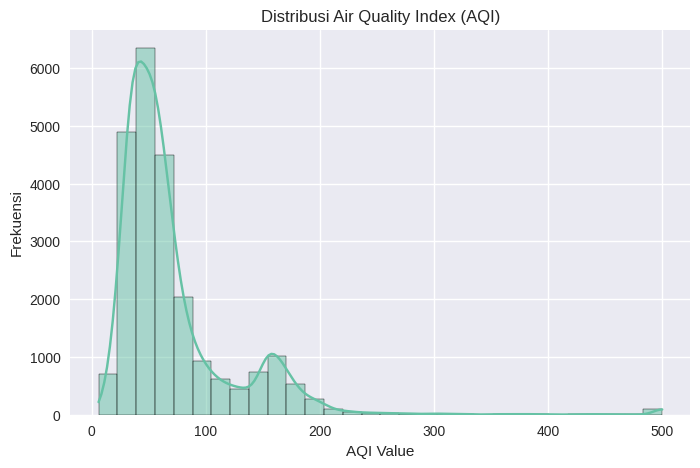

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['aqi_value'], bins=30, kde=True)
plt.title('Distribusi Air Quality Index (AQI)')
plt.xlabel('AQI Value')
plt.ylabel('Frekuensi')
plt.show()

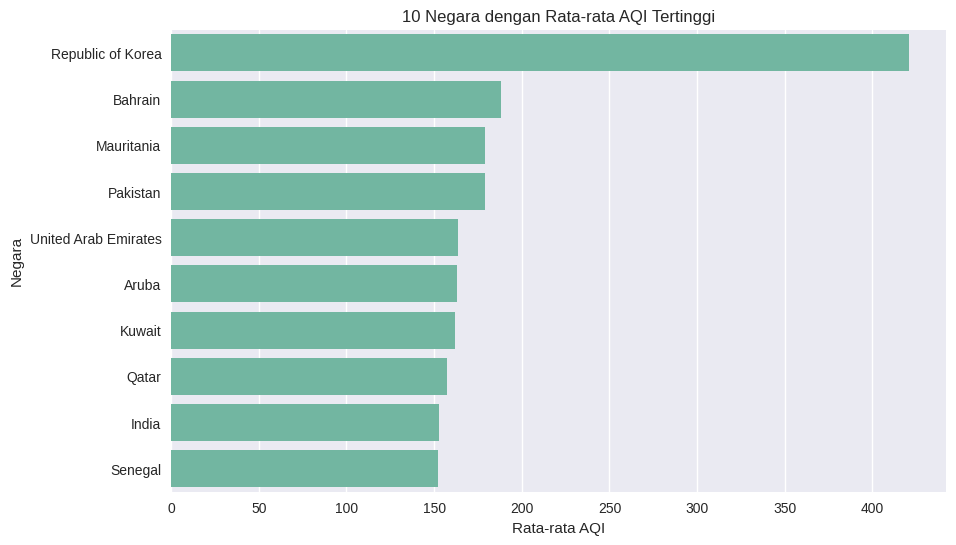

In [21]:
top_countries = df.groupby('country')['aqi_value'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('10 Negara dengan Rata-rata AQI Tertinggi')
plt.xlabel('Rata-rata AQI')
plt.ylabel('Negara')
plt.show()

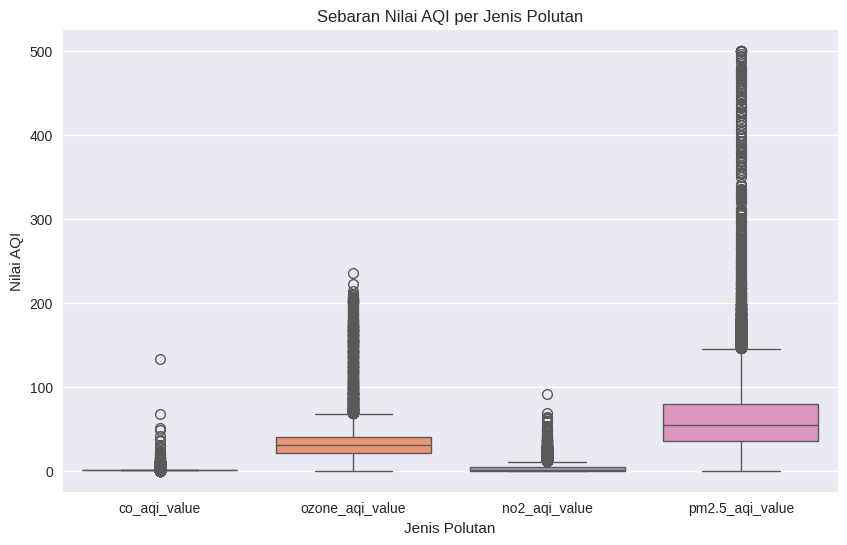

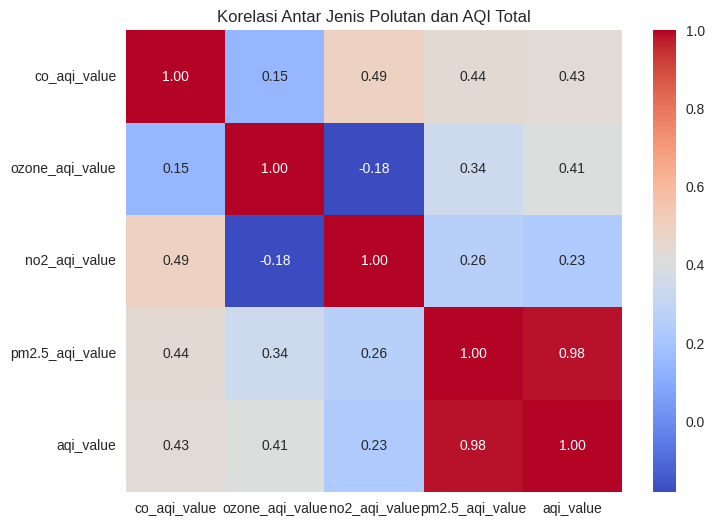

In [23]:
pollutants = ['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value']

plt.figure(figsize=(10,6))
sns.boxplot(data=df[pollutants])
plt.title('Sebaran Nilai AQI per Jenis Polutan')
plt.xlabel('Jenis Polutan')
plt.ylabel('Nilai AQI')
plt.show()

# Korelasi antar polutant
corr = df[pollutants + ['aqi_value']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Antar Jenis Polutan dan AQI Total')
plt.show()

# Clustering (Coba coba sebelum modelling)

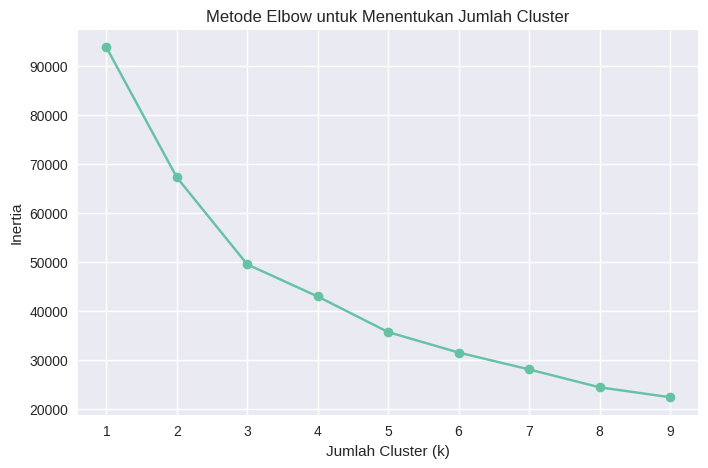

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pollutant_cols = ['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value']

X = df[pollutant_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.show()

In [26]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


print(df['cluster'].value_counts())

cluster_summary = df.groupby('cluster')[pollutant_cols + ['aqi_value']].mean().round(2)
display(cluster_summary)

cluster
0    16879
3     4537
1     1384
2      663
Name: count, dtype: int64


,co_aqi_value,ozone_aqi_value,no2_aqi_value,pm2.5_aqi_value,aqi_value
cluster,,,,,
0,0.88,31.37,1.31,45.64,49.06
1,2.82,124.43,2.36,182.38,199.28
2,6.87,14.92,23.89,155.26,155.44
3,1.92,25.16,6.74,106.24,106.37


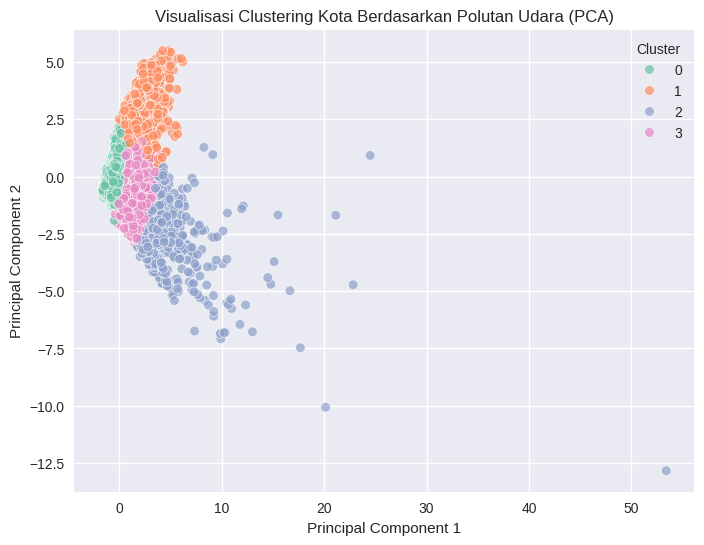

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df['pca1'] = pca_result[:,0]
df['pca2'] = pca_result[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    data=df,
    palette='Set2',
    alpha=0.7
)
plt.title('Visualisasi Clustering Kota Berdasarkan Polutan Udara (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


In [30]:
display(df.head())

,country,city,aqi_value,aqi_category,co_aqi_value,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category,cluster,pca1,pca2
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,0,-0.583822,0.275122
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,0,-0.851784,-0.737169
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,0,-0.217923,0.227783
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,0,-0.922357,0.057379
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good,0,-1.505877,-0.279428


In [31]:
df.to_csv('clustered_global_air_pollution.csv', index=False)

# Geo Clustering

In [32]:
!pip install plotly geopy

import plotly.express as px
from geopy.geocoders import Nominatim
from tqdm import tqdm

In [34]:
geolocator = Nominatim(user_agent="geoapi")

sample_df = df.sample(200, random_state=42).copy()

tqdm.pandas()

def get_coordinates(city, country):
    try:
        location = geolocator.geocode(f"{city}, {country}")
        if location:
            return pd.Series([location.latitude, location.longitude])
    except:
        return pd.Series([None, None])
    return pd.Series([None, None])

sample_df[['latitude', 'longitude']] = sample_df.progress_apply(
    lambda x: get_coordinates(x['city'], x['country']), axis=1
)

fig = px.scatter_geo(
    sample_df,
    lat="latitude",
    lon="longitude",
    color="cluster",
    hover_name="city",
    hover_data=["country", "aqi_value", "aqi_category"],
    title="Geo Clustering of Global Air Pollution",
    projection="natural earth",
    color_continuous_scale="Viridis"
)
fig.show()

100%|██████████| 200/200 [05:55<00:00,  1.78s/it]


# Analisis Hubungan antara Cluster dan Kategori AQI

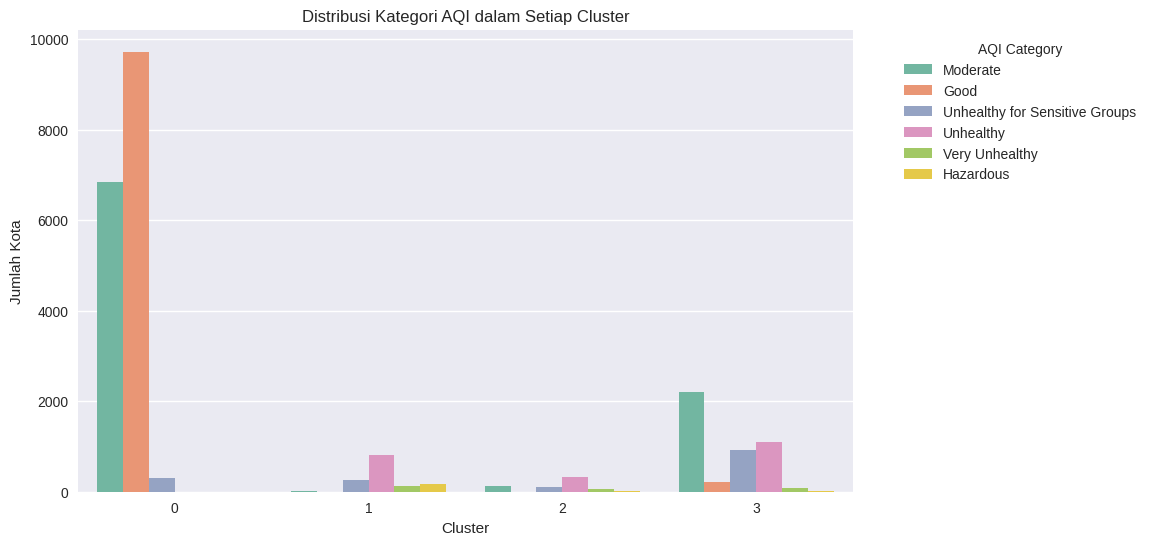

,cluster,aqi_category,aqi_value
0,0,Good,36.30
1,0,Moderate,64.42
2,0,Unhealthy for Sensitive Groups,111.49
3,1,Hazardous,454.29
4,1,Moderate,93.62
5,1,Unhealthy,170.11
6,1,Unhealthy for Sensitive Groups,127.84
7,1,Very Unhealthy,223.22
8,2,Good,40.00
9,2,Hazardous,390.50


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='cluster', hue='aqi_category')
plt.title('Distribusi Kategori AQI dalam Setiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Kota')
plt.legend(title='AQI Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

cluster_aqi_summary = df.groupby(['cluster', 'aqi_category'])['aqi_value'].mean().round(2).reset_index()
display(cluster_aqi_summary)


# Model Training

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value']]
y = df['aqi_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data train:", X_train.shape)
print("Data test :", X_test.shape)

Data train: (18770, 4)
Data test : (4693, 4)


* Regresi Linear

📈 Linear Regression Results:
Mean Absolute Error (MAE): 4.8
R² Score: 0.976


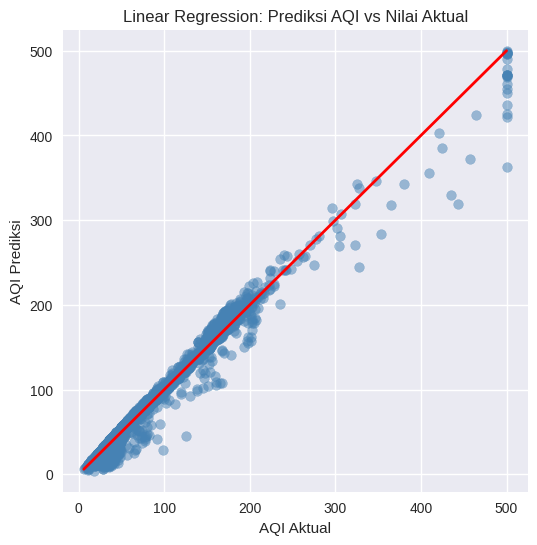

In [38]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("📈 Linear Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_lr, 2))
print("R² Score:", round(r2_lr, 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Linear Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()


🌳 Random Forest Results:
Mean Absolute Error (MAE): 0.23
R² Score: 0.998


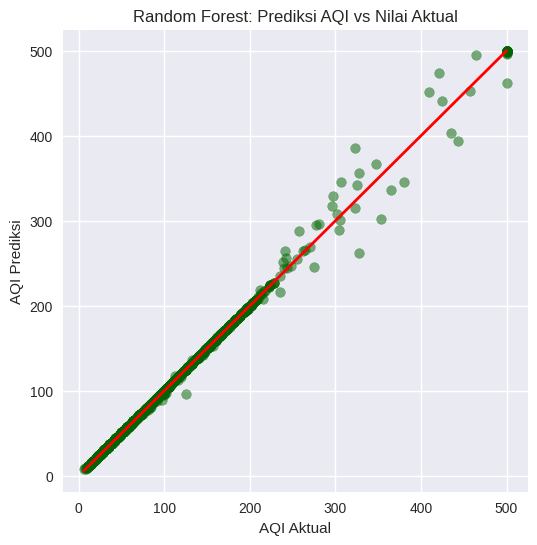

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("🌳 Random Forest Results:")
print("Mean Absolute Error (MAE):", round(mae_rf, 2))
print("R² Score:", round(r2_rf, 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='darkgreen')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Random Forest: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()
